# Statistics sheet 6

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import binom

from enum import Enum
plt.style.use('science')
plt.rcParams.update({'font.size': 14})

## Exercise 1: lighthouse problem

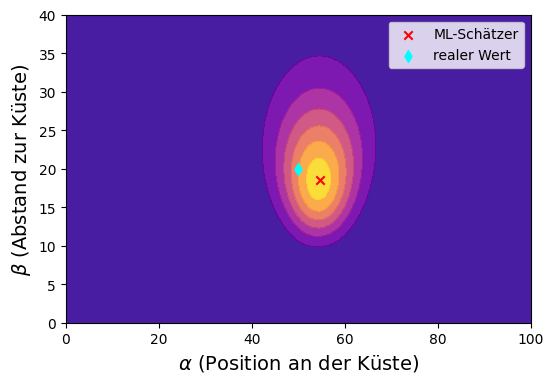

In [ ]:
# a)
alpha = 50
beta = 20
N = 100

a_ML = np.linspace(0,100, N)
b_ML = np.linspace(0,40,N)

x_n = alpha + beta * np.random.standard_t(1, 20)

# b)
A, B = np.meshgrid(a_ML, b_ML, indexing='ij')
p_alpha_beta = 1
for x_i in x_n:
    p_alpha_beta *= 1/np.pi * B / ((x_i - A)**2 + B**2) 

p_alpha_beta /= np.sum(p_alpha_beta)

# c)
i_flat = np.argmax(p_alpha_beta)

i_alpha, i_beta = i_flat // N, i_flat % N
alpha_ML = a_ML[i_alpha]
beta_ML = b_ML[i_beta]

fig, ax = plt.subplots(1,1,figsize=(6, 4))

# 3D-Oberflächenplot
contour1 = ax.contourf(A, B, p_alpha_beta, cmap='plasma', alpha=0.9)

# Markierung des ML-Schätzers im Plot
ax.scatter(alpha_ML, beta_ML, color='red', marker='x', label='ML-Schätzer')
ax.scatter(alpha, beta, color='cyan', marker='d', label='realer Wert')

ax.set_xlabel(r'$\alpha$ (Position an der Küste)', fontsize=14)
ax.set_ylabel(r'$\beta$ (Abstand zur Küste)', fontsize=14)
ax.legend()

plt.show()

## Exercise 2: CLT

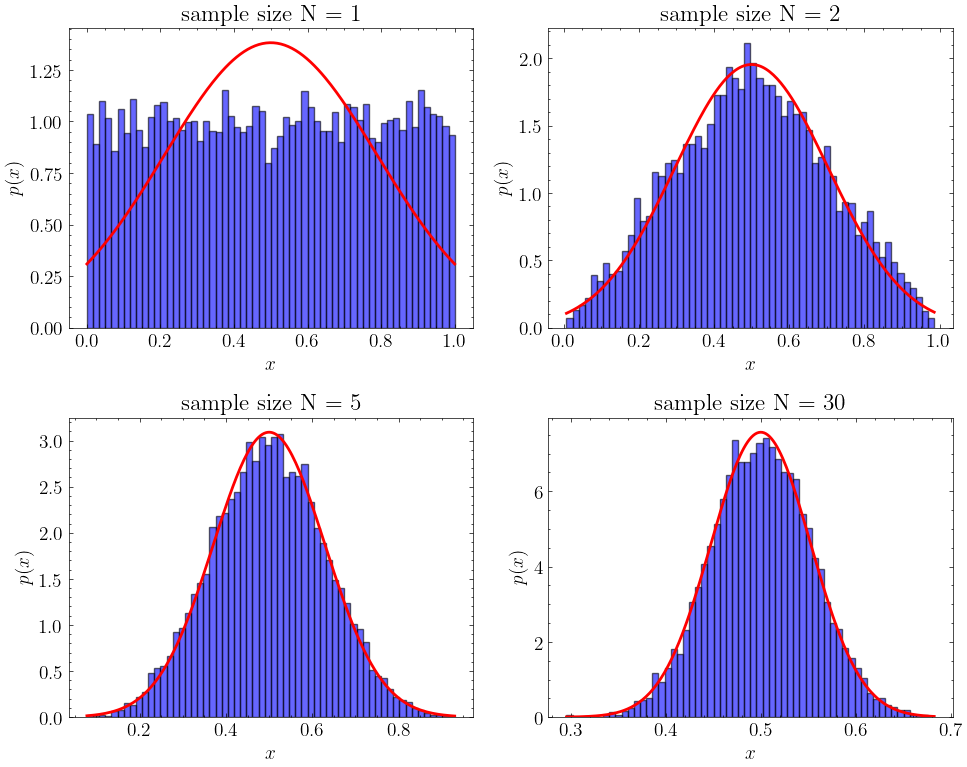

In [31]:
L = 10000
N_values = [1, 2, 5, 30] 

class Distributions(Enum):
    UNIFORM = 1
    CHI_SQUARED = 2
    BETA = 3
    EXPONENTIAL = 4

chosen_dist = Distributions.UNIFORM

fig, axes = plt.subplots(2,2,figsize=(10, 8))

for i, N in enumerate(N_values):
    
    if chosen_dist == Distributions.UNIFORM:
        mu = 0.5
        sig = 1.0 / 12.0
        sample = np.random.uniform(size=(L, N))
    elif chosen_dist == Distributions.CHI_SQUARED:
        mu = 2
        sig = 4
        sample = np.random.chisquare(2, size=(L, N))
    elif chosen_dist == Distributions.BETA:
        mu = 0.5
        sig = 0.125
        sample = np.random.beta(0.5, 0.5, size=(L, N))
    elif chosen_dist == Distributions.EXPONENTIAL:
        mu = 2
        sig = 4
        sample = np.random.exponential(2, size=(L, N))

    s_l = np.mean(sample, axis=1)
    
    ax = axes[np.unravel_index(i, (2,2))]
    counts, bins, _ = ax.hist(s_l, bins=60, density=True, color='blue', edgecolor='black', alpha=0.6)

    x_axis = np.linspace(np.min(bins), np.max(bins), 200)
    sig_s = np.sqrt(sig / N)  
    g_x = (1.0 / np.sqrt(2 * np.pi * sig_s**2)) * np.exp(-1/2 * ((x_axis - mu) / sig_s)**2)
    ax.plot(x_axis, g_x, color='red', linewidth=2)
    
    ax.set_title(f'sample size N = {N}')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$p(x)$')

    
plt.tight_layout()
plt.show()


## Exercise 3: Sampling - uniform distribution

In [83]:
def Sampling(N, M, print_flag=False, plot_flag=False):

    num = np.random.randint(0, N + 1, size=M)
    
    mu_bar = np.mean(num)
    sigma_F = np.std(num, ddof=1) / np.sqrt(M)       
    
    p_i = np.bincount(num, minlength=N+1) / M

    if print_flag:
        print(f"Ergebnisse für N = {N}, M = {M}:")
        print(f"  Stichprobenmittelwert (μ_bar): {mu_bar:.4f}")
        print(f"  Standardfehler (sigma_F):      {sigma_F:.4f}\n")

    if plot_flag:
        plt.figure(figsize=(6, 4)) 
        x_n = np.arange(0, N + 1)
        
        plt.bar(x_n, p_i, alpha=0.6, color='blue')
        
        plt.axhline(y=1/M, color='crimson', linewidth=1.5)
        
        plt.title(f'Sampling (N = {N}, M = {M})')
        plt.xlabel('$x_i$')
        plt.ylabel('$p_i$')
        plt.show()
        
    return mu_bar, sigma_F

Sampling(N=10, M=5000, print_flag=True)
Sampling(N=200, M=200, print_flag=True)
Sampling(N=2000, M=15, print_flag=True)

N_z = 100
M_z = 300
counter = 0

for i in range(1000):
    mu_bar, sigma_F = Sampling(N_z, M_z)
    if mu_bar - sigma_F <= N_z/2 <= mu_bar + sigma_F:
        counter += 1

print(f'{counter} von {1000} Versuchen waren valide => {counter/1000:.3f}')

Ergebnisse für N = 10, M = 5000:
  Stichprobenmittelwert (μ_bar): 5.0288
  Standardfehler (sigma_F):      0.0448

Ergebnisse für N = 200, M = 200:
  Stichprobenmittelwert (μ_bar): 103.8150
  Standardfehler (sigma_F):      4.3302

Ergebnisse für N = 2000, M = 15:
  Stichprobenmittelwert (μ_bar): 1011.1333
  Standardfehler (sigma_F):      142.0604

681 von 1000 Versuchen waren valide => 0.681


## Exercise 4: Random Walk

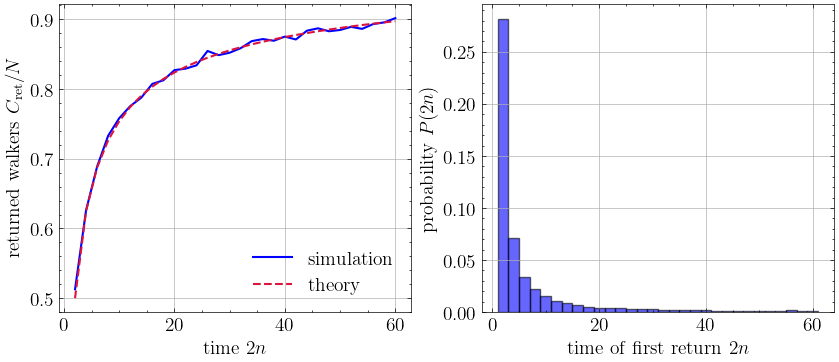

In [ ]:
def random_walk(max_time):
    pos = 0
    for i in range(max_time):
        if np.random.random_sample() < 0.5:
            pos -= 1
        else:
            pos += 1

        if pos == 0:
            return i + 1
    return 0
        
N = 10000
max_steps = 60
time = np.arange(2, max_steps + 1, 2)
m_vals = time // 2
return_counts = []

theo_cumulative_prob = 1.0 - binom.pmf(m_vals, 2 * m_vals, 0.5)

for t in time:
    r_count = 0
    for w in range(N):
        return_idx = random_walk(t)
        r_count += return_idx > 0
        
    return_counts.append(r_count)
return_counts = np.array(return_counts) / N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(time, return_counts, label="simulation", color="blue", linewidth=1.5)
ax1.plot(time, theo_cumulative_prob, label="theory", color="crimson", linestyle="--", linewidth=1.5)
ax1.set_xlabel(r"time $2n$")
ax1.set_ylabel(r"returned walkers $C_\text{ret}/N$")
ax1.legend()
ax1.grid(True)

return_times = []
for w0 in range(N):
    return_idx = random_walk(max_steps)
    return_times.append(return_idx)

bins = np.arange(1, max_steps + 3, 2)
ax2.hist(return_times, bins=bins, density=True, alpha=0.6, color="blue", edgecolor="black")

ax2.set_xlabel("time of first return $2n$")
ax2.set_ylabel("probability $P(2n)$")
ax2.grid(True)

## Exercise 5: MCMC linear fit

5.3386207026645 1.9015878625395868


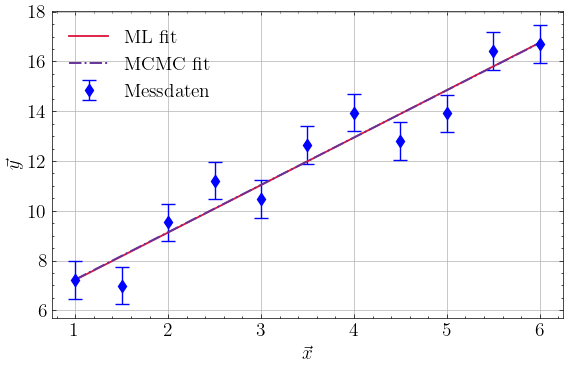

In [91]:
data = np.loadtxt('mcmc.dat')
x,y = data
sigma = 0.75

N = len(x)
x_bar = np.mean(x)
y_bar = np.mean(y)
xy_bar = np.mean(x*y)
x_bar_sq = np.mean(x**2)

# b) --- ML - Calculation ---
# A = [[N, N*x_bar], [N*x_bar, np.sum(x**2)]]
# B = [N*y_bar, np.sum(x*y)]
# a,b = np.linalg.solve(A,B)
# print(a,b)

V_x, C_xy = np.cov(x, y)[0]
b_ML = C_xy / V_x
a_ML = y_bar - b_ML * x_bar

# c) --- MCMC - Calculation ---
a, b = 3, 1
da, db = 0.5, 0.5
N_mess = 10000
N_skip = 20
N_loop = N_mess*N_skip

list_corr = np.zeros((N_loop, 2))

for i in range(N_loop):
    a_t = a + (np.random.rand() - 0.5)*da
    b_t = b + (np.random.rand() - 0.5)*db

    delta_Phi = (
        (a_t**2 - a**2) + x_bar_sq * (b_t**2 - b**2)
        - 2 * y_bar * (a_t - a) - 2 * xy_bar * (b_t - b)
        + 2 * x_bar * (a_t * b_t - a*b)
    )
    if np.random.rand() < min(np.exp(-N / (2 * sigma**2) * delta_Phi), 1):
        a, b = a_t, b_t

    list_corr[i, :] = (a,b)

list_sample = list_corr[::20]
a_mean, b_mean = np.mean(list_sample, axis=0)
print(a_mean, b_mean)

x_fine = np.linspace(min(x), max(x), 1000)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(x, y, yerr=sigma, fmt='bd', capsize=5, label='Messdaten')
ax.plot(x_fine, a_ML + b_ML*x_fine, color='crimson', lw=1.3, linestyle='-', label='ML fit')
ax.plot(x_fine, a_mean + b_mean*x_fine, color='rebeccapurple', lw=1.4,  linestyle='-.', label='MCMC fit')
ax.set_xlabel(r'$\vec x$')
ax.set_ylabel(r'$\vec y$')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

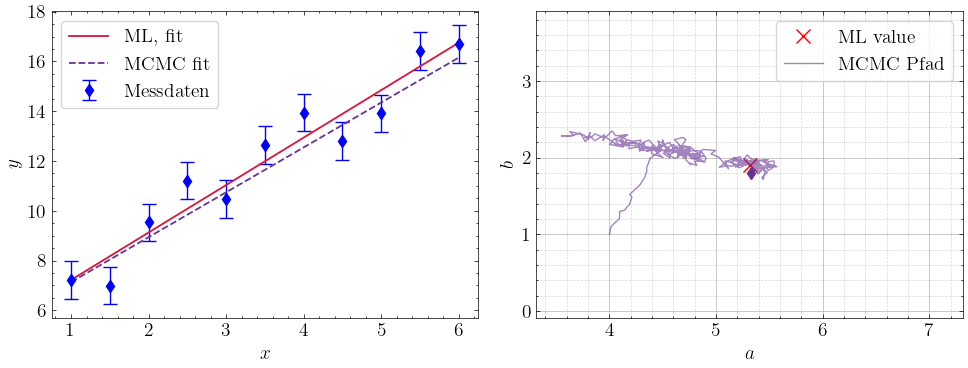

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

data = np.loadtxt('mcmc.dat')
x, y = data
sigma = 0.75

N = len(x)
x_bar = np.mean(x)
y_bar = np.mean(y)
xy_bar = np.mean(x*y)
x2_bar = np.mean(x**2)

# b) --- ML - Calculation ---
cov_matrix = np.cov(x, y)
V_x = cov_matrix[0, 0]
C_xy = cov_matrix[0, 1]
b_ML = C_xy / V_x
a_ML = y_bar - b_ML * x_bar

# c) --- MCMC Setup für die Animation ---
a, b = 4.0, 1.0  # Startwerte
da, db = 0.1, 0.1

# Für eine flüssige Animation wählen wir weniger Schritte als in der Hauptmessung
n_frames = 300 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Linker Plot: Daten und Linien
ax1.errorbar(x, y, yerr=sigma, fmt='bd', capsize=5, label='Messdaten')
x_fine = np.linspace(min(x), max(x), 1000)
ax1.plot(x_fine, a_ML + b_ML*x_fine, color='crimson', lw=1.3, linestyle='-', label='ML, fit')
line_mcmc, = ax1.plot([], [], color='rebeccapurple', lw=1.3, linestyle='--', label='MCMC fit')
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.legend(frameon=True)
ax2.grid(True, which='major')
ax2.grid(True, alpha=0.5, ls='--', which='minor')

# Rechter Plot: Parameterraum (a, b)
ax2.plot(a_ML, b_ML, 'rx', markersize=10, label='ML value')
path_mcmc, = ax2.plot([], [], color='rebeccapurple', linestyle='-', alpha=0.6, label='MCMC Pfad')
point_mcmc, = ax2.plot([], [], color='rebeccapurple', linestyle='none', marker='d', markersize=6)
ax2.set_xlim(a_ML - 2, a_ML + 2)
ax2.set_ylim(b_ML - 2, b_ML + 2)
ax2.set_xlabel(r'$a$')
ax2.set_ylabel(r'$b$')
ax2.legend(frameon=True)
ax2.grid(True, which='major')
ax2.grid(True, alpha=0.5, ls='--', which='minor')

# Listen zum Speichern des Verlaufs für die Visualisierung
a_history = [a]
b_history = [b]

def init():
    line_mcmc.set_data([], [])
    path_mcmc.set_data([], [])
    point_mcmc.set_data([], [])
    return line_mcmc, path_mcmc, point_mcmc

def update(frame):
    global a, b
    
    # Wir machen pro Frame 5 interne MCMC-Schritte, damit es schneller konvergiert
    for _ in range(5):
        a_t = a + (np.random.rand() - 0.5) * da
        b_t = b + (np.random.rand() - 0.5) * db

        delta_Phi = (
            (a_t**2 - a**2) + x2_bar * (b_t**2 - b**2)
            - 2 * y_bar * (a_t - a) - 2 * xy_bar * (b_t - b)
            + 2 * x_bar * (a_t * b_t - a*b)
        )
        if np.random.rand() < min(np.exp(-N / (2 * sigma**2) * delta_Phi), 1):
            a, b = a_t, b_t

    a_history.append(a)
    b_history.append(b)

    # Update der Geraden im linken Plot
    line_mcmc.set_data(x_fine, a + b * x_fine)

    # Update des Pfads im rechten Plot
    path_mcmc.set_data(a_history, b_history)
    point_mcmc.set_data([a], [b])

    return line_mcmc, path_mcmc, point_mcmc

ani = animation.FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=50, repeat=False)
ani.save('mcmc_anim.gif')
plt.tight_layout()
plt.show()